<a href="https://colab.research.google.com/github/F-Lepin/OBBO-FIRE-TEST/blob/main/quemas_ufro_uapif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SISTEMA DE MONITOREO DE QUEMAS AGRÍCOLAS POR SEMANA
# Adaptado para procesamiento masivo en Google Earth Engine
# ============================================================

# ── 0. INSTALAR Y AUTENTICAR ────────────────────────────────
!pip install earthengine-api geopandas shapely geemap --quiet
import ee
import geemap
import os
import geopandas as gpd
import pandas as pd

# Autenticación (Descomentar la primera vez en la sesión)
ee.Authenticate()
ee.Initialize(project='conaf-478214')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# FUNCIONES AUXILIARES (SENTINEL-2 Y CÁLCULOS)
# ============================================================
def maskS2sr(image):
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    qa = image.select('QA60')
    mask = (qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0)))
    return image.updateMask(mask).copyProperties(image, ["system:time_start"])

def adddate(image):
    return image.addBands(image.metadata('system:time_start'))


def get_INDEX_S2(image):
    NDVI = image.expression('(NIR - Red) / (NIR + Red)',
        {'NIR': image.select('B8'), 'Red': image.select('B4')}
    ).rename('NDVI')

    # ✅  valores entre -1 y 1
    NBR = image.expression('(NIR - SWIR2) / (NIR + SWIR2)',
        {'NIR': image.select('B8'), 'SWIR2': image.select('B12')}
    ).rename('NBR')

    return image.addBands(NDVI).addBands(NBR).copyProperties(image, ['system:time_start', 'system:time_end'])

def renameBandsS2(image):
    bands     = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NBR']
    new_bands = ['B',  'G',  'R',  'NIR','SWIR1','SWIR2','NDVI', 'NBR']
    return image.select(bands).rename(new_bands)

In [ ]:
# ============================================================
# BOX 1 — CARGA Y CRUCE ESPACIAL LOCAL (GEOPANDAS)
# ============================================================
path_quemas = "/content/drive/MyDrive/UFRO-UAPIF/analisis_ufro_uapif/imputs/capa_quemas_ejecutadas_GEE/aviso_quemas_unida_DMS_4326_v2.shp"
path_roles  = "/content/drive/MyDrive/UFRO-UAPIF/analisis_ufro_uapif/imputs/roles 2013/ARA_ROLES_2013_EPSG4326.shp"

print("Cargando y cruzando capas...")
quemas_gpd = gpd.read_file(path_quemas)
roles_gpd = gpd.read_file(path_roles)

try:
    roles_gpd = roles_gpd[['ROL', 'AREA_HA', 'geometry']]
except KeyError as e:
    print(f"Revisa el nombre de la columna: {e}")

if roles_gpd.crs != quemas_gpd.crs:
    quemas_gpd = quemas_gpd.to_crs(roles_gpd.crs)

roles_intersectados = gpd.sjoin(roles_gpd, quemas_gpd, how="inner", predicate='intersects')

Cargando y cruzando capas...


Es necesario mejorar la interseccion entre los roles, es posible que hayan cambiado con el tiempo, por lo que la interseccion mejoraria si se hace a partir de la columna roles y no por ubicacion

In [ ]:
# ============================================================
# BOX 2 — PREPARACIÓN TEMPORAL (AGRUPACIÓN POR SEMANA)
# ============================================================
print("Organizando datos por semanas temporales...")
datos_limpios = roles_intersectados.dropna(subset=['inicioano', 'iniciomes', 'iniciodia']).copy()

datos_limpios['inicioano'] = datos_limpios['inicioano'].astype(int)
datos_limpios['iniciomes'] = datos_limpios['iniciomes'].astype(int)
datos_limpios['iniciodia'] = datos_limpios['iniciodia'].astype(int)

datos_limpios['fecha_inicio'] = pd.to_datetime(
    datos_limpios[['inicioano', 'iniciomes', 'iniciodia']].rename(
        columns={'inicioano': 'year', 'iniciomes': 'month', 'iniciodia': 'day'})
)

datos_limpios['semana_iso'] = datos_limpios['fecha_inicio'].dt.isocalendar().week
datos_limpios['anio_iso'] = datos_limpios['fecha_inicio'].dt.isocalendar().year
datos_limpios['periodo_semanal'] = datos_limpios['anio_iso'].astype(str) + "-W" + datos_limpios['semana_iso'].astype(str).str.zfill(2)

semanas_unicas = datos_limpios['periodo_semanal'].sort_values().unique()


print(f"Total de semanas a procesar: {len(semanas_unicas)}\n")

Organizando datos por semanas temporales...
Total de semanas a procesar: 45



--- 1. Muestra de la tabla generada ---
        inicioano  iniciomes  iniciodia fecha_inicio  semana_iso  \
142861       2025          3         21   2025-03-21          12   
84197        2025          4          7   2025-04-07          15   
82113        2025          4         29   2025-04-29          18   
142052       2025          3         21   2025-03-21          12   
142164       2025          4          8   2025-04-08          15   
95993        2025          4          6   2025-04-06          14   
121788       2025          4          8   2025-04-08          15   
140943       2025          4         10   2025-04-10          15   
102831       2024         11         22   2024-11-22          47   
96122        2025          4          6   2025-04-06          14   

       periodo_semanal  
142861        2025-W12  
84197         2025-W15  
82113         2025-W18  
142052        2025-W12  
142164        2025-W15  
95993         2025-W14  
121788        2025-W15  
140943     

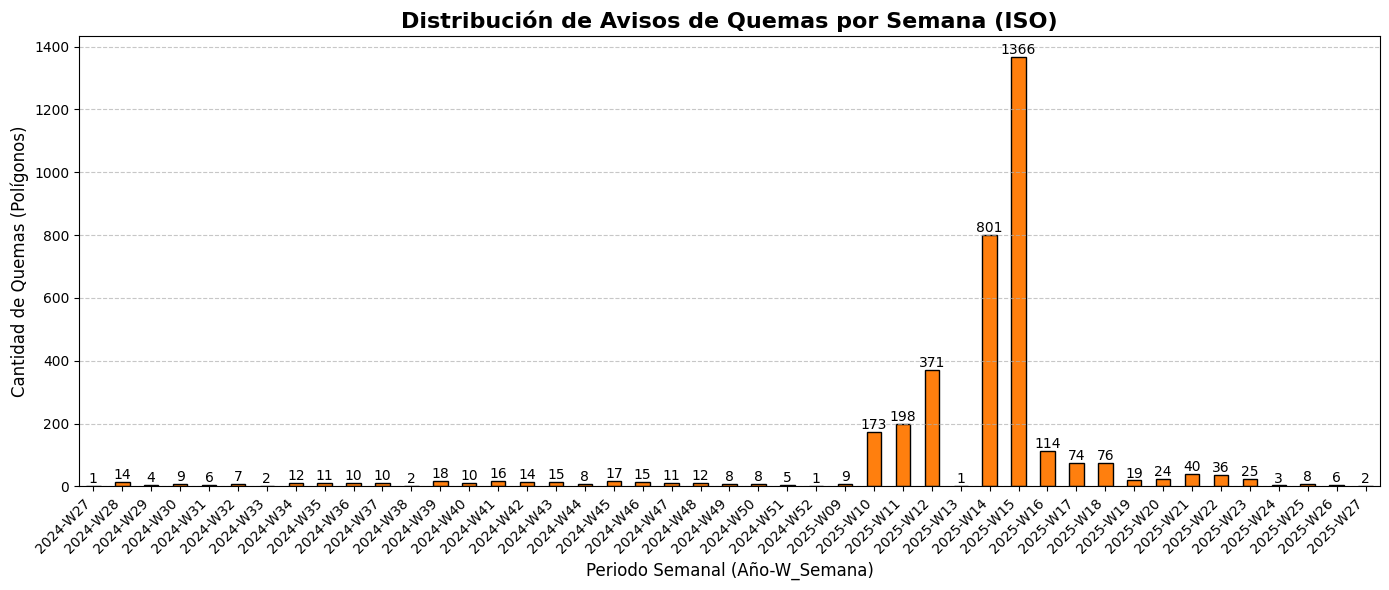

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# VERIFICACIÓN DE LA AGRUPACIÓN SEMANAL
# ============================================================

print("--- 1. Muestra de la tabla generada ---")
# Seleccionamos unas cuantas filas al azar para ver si la fecha calculada tiene sentido
# respecto a las columnas originales de día, mes y año.
columnas_verificacion = ['inicioano', 'iniciomes', 'iniciodia', 'fecha_inicio', 'semana_iso', 'periodo_semanal']
print(datos_limpios[columnas_verificacion].sample(10, replace=True)) # Usamos sample para ver variedad
print("\n")

print("--- 2. Resumen de quemas por semana ---")
# Contamos cuántos predios se queman en cada semana y ordenamos cronológicamente
resumen_semanal = datos_limpios['periodo_semanal'].value_counts().sort_index()
print(resumen_semanal)
print("\n")

# ============================================================
# GRÁFICO DE BARRAS
# ============================================================
print("--- 3. Generando gráfico de distribución ---")

plt.figure(figsize=(14, 6))
ax = resumen_semanal.plot(kind='bar', color='#ff7f0e', edgecolor='black')

# Añadir valores exactos encima de cada barra
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Configuraciones del gráfico
plt.title('Distribución de Avisos de Quemas por Semana (ISO)', fontsize=16, fontweight='bold')
plt.xlabel('Periodo Semanal (Año-W_Semana)', fontsize=12)
plt.ylabel('Cantidad de Quemas (Polígonos)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico en Colab
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# DIAGNÓSTICO
# ============================================================
semana_test = "2025-W15"  # Cambia esto a la semana que quieras probar

print(f"=== DIAGNÓSTICO: {semana_test} ===\n")

# Datos locales
quemas_semana_gpd = datos_limpios[datos_limpios['periodo_semanal'] == semana_test]
fc_semana = geemap.gdf_to_ee(quemas_semana_gpd)
bounds_semana = quemas_semana_gpd.total_bounds
region = ee.Geometry.Rectangle([bounds_semana[0], bounds_semana[1], bounds_semana[2], bounds_semana[3]])

fecha_min = quemas_semana_gpd['fecha_inicio'].min()
fecha_max = quemas_semana_gpd['fecha_inicio'].max()

inicio_str = (fecha_min - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
inibf_str  = (fecha_min - pd.Timedelta(days=21)).strftime('%Y-%m-%d')
fin_str    = (fecha_max + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
finbf_str  = (fecha_max + pd.Timedelta(days=21)).strftime('%Y-%m-%d')

print(f"Predios en esta semana: {len(quemas_semana_gpd)}")
print(f"Fechas de quema: {fecha_min.date()} → {fecha_max.date()}")
print(f"Ventana PRE:  {inibf_str} → {inicio_str}")
print(f"Ventana POST: {fin_str} → {finbf_str}")
print(f"Bbox región: {bounds_semana}\n")

# ── Imágenes disponibles ─────────────────────────────────────
sat_base = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
              .filterBounds(region)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
              .map(get_INDEX_S2).map(maskS2sr).map(renameBandsS2))

col_pre = sat_base.filterDate(inibf_str, inicio_str)
col_pos = sat_base.filterDate(fin_str, finbf_str)

n_pre = col_pre.size().getInfo()
n_pos = col_pos.size().getInfo()
print(f"Imágenes PRE disponibles (nubes < 20%): {n_pre}")
print(f"Imágenes POST disponibles (nubes < 20%): {n_pos}")

# Si hay 0 imágenes, probar con umbral de nubosidad más alto
sat_50 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(region)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50)))
n_pre_50 = sat_50.filterDate(inibf_str, inicio_str).size().getInfo()
n_pos_50 = sat_50.filterDate(fin_str, finbf_str).size().getInfo()
print(f"Imágenes PRE disponibles (nubes < 50%): {n_pre_50}")
print(f"Imágenes POST disponibles (nubes < 50%): {n_pos_50}\n")

# ── Estadísticas del mosaico ─────────────────────────────────
if n_pre > 0 and n_pos > 0:
    mosaic_pre = col_pre.map(adddate).median().clip(region)
    mosaic_pos = col_pos.map(adddate).median().clip(region)

    # Valores reales de NBR en la región
    stats_nbr_pre = mosaic_pre.select('NBR').reduceRegion(
        reducer=ee.Reducer.percentile([10, 50, 90]),
        geometry=region, scale=100, maxPixels=int(1e9)
    ).getInfo()
    stats_nbr_pos = mosaic_pos.select('NBR').reduceRegion(
        reducer=ee.Reducer.percentile([10, 50, 90]),
        geometry=region, scale=100, maxPixels=int(1e9)
    ).getInfo()

    print(f"Estadísticas NBR PRE  (p10/p50/p90): {stats_nbr_pre}")
    print(f"Estadísticas NBR POST (p10/p50/p90): {stats_nbr_pos}\n")

    # dNBR real
    dNBR = mosaic_pre.select('NBR').subtract(mosaic_pos.select('NBR'))
    stats_dnbr = dNBR.reduceRegion(
        reducer=ee.Reducer.percentile([10, 25, 50, 75, 90]),
        geometry=region, scale=100, maxPixels=int(1e9)
    ).getInfo()
    print(f"Estadísticas dNBR (p10/p25/p50/p75/p90): {stats_dnbr}\n")

    # RdNBR real
    RdNBR = dNBR.divide(mosaic_pre.select('NBR').abs().sqrt()).rename('RdNBR')
    stats_rdnbr = RdNBR.reduceRegion(
        reducer=ee.Reducer.percentile([10, 25, 50, 75, 90, 95, 99]),
        geometry=region, scale=100, maxPixels=int(1e9)
    ).getInfo()
    print(f"Estadísticas RdNBR (p10→p99): {stats_rdnbr}\n")

    # Cuántos píxeles superan distintos umbrales
    for umbral in [0.1, 0.2, 0.3, 0.5, 1.0, 2.0]:
        pixeles = RdNBR.gt(umbral).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=region, scale=100, maxPixels=int(1e9)
        ).getInfo()
        area_ha = list(pixeles.values())[0] * 100 * 100 / 10000 if pixeles else 0
        print(f"  Umbral RdNBR > {umbral:.1f} → {area_ha:.1f} ha detectadas")

    # ── Estadísticas NDVI ────────────────────────────────────
    print()
    stats_ndvi_pre = mosaic_pre.select('NDVI').reduceRegion(
        reducer=ee.Reducer.percentile([10, 50, 90]),
        geometry=region, scale=100, maxPixels=int(1e9)
    ).getInfo()
    stats_ndvi_pos = mosaic_pos.select('NDVI').reduceRegion(
        reducer=ee.Reducer.percentile([10, 50, 90]),
        geometry=region, scale=100, maxPixels=int(1e9)
    ).getInfo()
    print(f"Estadísticas NDVI PRE  (p10/p50/p90): {stats_ndvi_pre}")
    print(f"Estadísticas NDVI POST (p10/p50/p90): {stats_ndvi_pos}")

    # ── NIR post ────────────────────────────────────────────
    stats_nir = mosaic_pos.select('NIR').reduceRegion(
        reducer=ee.Reducer.percentile([10, 50, 90]),
        geometry=region, scale=100, maxPixels=int(1e9)
    ).getInfo()
    print(f"Estadísticas NIR POST  (p10/p50/p90): {stats_nir}")

else:
    print("❌ No hay imágenes suficientes — ajustar umbral de nubosidad o ventana temporal")

=== DIAGNÓSTICO: 2025-W15 ===



Predios en esta semana: 1366
Fechas de quema: 2025-04-07 → 2025-04-12
Ventana PRE:  2025-03-17 → 2025-04-06
Ventana POST: 2025-04-13 → 2025-05-03
Bbox región: [-73.3641932  -39.37857138 -71.27212547 -37.66209739]

Imágenes PRE disponibles (nubes < 20%): 56
Imágenes POST disponibles (nubes < 20%): 34
Imágenes PRE disponibles (nubes < 50%): 73
Imágenes POST disponibles (nubes < 50%): 50

Estadísticas NBR PRE  (p10/p50/p90): {'NBR_p10': 0.04297299625404696, 'NBR_p50': 0.5195398147562528, 'NBR_p90': 0.7616587125108573}
Estadísticas NBR POST (p10/p50/p90): {'NBR_p10': 0.054767953873693175, 'NBR_p50': 0.5703711289802823, 'NBR_p90': 0.7889134217671807}

Estadísticas dNBR (p10/p25/p50/p75/p90): {'NBR_p10': -0.16382178480205306, 'NBR_p25': -0.08563742116236561, 'NBR_p50': -0.0386751229625884, 'NBR_p75': -0.008423572599735899, 'NBR_p90': 0.06993588261920922}

Estadísticas RdNBR (p10→p99): {'RdNBR_p10': -0.17950335253916033, 'RdNBR_p25': -0.17950335253916033, 'RdNBR_p50': -0.17950335253916033, 'R

In [ ]:
# ============================================================
# CONFIGURACIÓN DE EJECUCIÓN — MODIFICAR AQUÍ ANTES DE CORRER
# ============================================================

MODO_EJECUCION = "seleccion"  # Opciones: "todas" | "rango" | "seleccion"

# Solo se usa si MODO_EJECUCION = "seleccion"
SEMANAS_SELECCIONADAS = ["2025-W15"]

# Solo se usa si MODO_EJECUCION = "rango"
SEMANA_DESDE = "2024-W27"
SEMANA_HASTA = "2024-W35"

# Umbral RdNBR (ajustar para pruebas)
ind_RdNBR = 2  # ajustar

# Carpeta raíz de resultados en Drive
OUTPUT_ROOT = "/content/drive/MyDrive/UFRO-UAPIF/analisis_ufro_uapif/resultados"

# ============================================================
# SELECCIÓN DE SEMANAS SEGÚN MODO
# ============================================================
semanas_todas = list(semanas_unicas)  # Ya calculadas en BOX 2

if MODO_EJECUCION == "todas":
    semanas_a_procesar = semanas_todas
    print(f"Modo: TODAS — {len(semanas_a_procesar)} semanas a procesar")

elif MODO_EJECUCION == "rango":
    semanas_a_procesar = [s for s in semanas_todas if SEMANA_DESDE <= s <= SEMANA_HASTA]
    print(f"Modo: RANGO [{SEMANA_DESDE} → {SEMANA_HASTA}] — {len(semanas_a_procesar)} semanas encontradas")

elif MODO_EJECUCION == "seleccion":
    semanas_a_procesar = [s for s in SEMANAS_SELECCIONADAS if s in semanas_todas]
    no_encontradas = [s for s in SEMANAS_SELECCIONADAS if s not in semanas_todas]
    if no_encontradas:
        print(f"⚠️  Semanas no encontradas en los datos: {no_encontradas}")
    print(f"Modo: SELECCIÓN — {len(semanas_a_procesar)} semanas a procesar: {semanas_a_procesar}")

else:
    raise ValueError(f"MODO_EJECUCION '{MODO_EJECUCION}' no válido. Usa 'todas', 'rango' o 'seleccion'.")

print(f"Umbral RdNBR: {ind_RdNBR}")
print(f"Carpeta de salida: {OUTPUT_ROOT}\n")


Modo: SELECCIÓN — 1 semanas a procesar: ['2025-W15']
Umbral RdNBR: 2
Carpeta de salida: /content/drive/MyDrive/UFRO-UAPIF/analisis_ufro_uapif/resultados



In [ ]:
# ============================================================
# BOX 3 a 6 — BUCLE DE ANÁLISIS SATELITAL POR SEMANA
# ============================================================
import os

for semana in semanas_a_procesar:
    print(f"============================================================")
    print(f"PROCESANDO SEMANA: {semana}")

    # ── Crear subcarpeta por semana ──────────────────────────
    carpeta_semana = os.path.join(OUTPUT_ROOT, f"semana_{semana}")
    os.makedirs(carpeta_semana, exist_ok=True)
    print(f"  Carpeta de salida: {carpeta_semana}")

    # 1. Filtrar datos locales y subir a EE
    quemas_semana_gpd = datos_limpios[datos_limpios['periodo_semanal'] == semana]
    fc_semana = geemap.gdf_to_ee(quemas_semana_gpd)

    bounds_semana = quemas_semana_gpd.total_bounds
    region = ee.Geometry.Rectangle([bounds_semana[0], bounds_semana[1], bounds_semana[2], bounds_semana[3]])

    # 2. Definir Fechas
    fecha_min = quemas_semana_gpd['fecha_inicio'].min()
    fecha_max = quemas_semana_gpd['fecha_inicio'].max()

    inicio_str = (fecha_min - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    inibf_str  = (fecha_min - pd.Timedelta(days=21)).strftime('%Y-%m-%d')
    fin_str    = (fecha_max + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    finbf_str  = (fecha_max + pd.Timedelta(days=21)).strftime('%Y-%m-%d')

    print(f"  Pre:  {inibf_str} → {inicio_str}")
    print(f"  Post: {fin_str} → {finbf_str}")

    # 3. Mosaicos Sentinel-2
    sat = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
             .filterBounds(region)
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
             .map(get_INDEX_S2).map(maskS2sr).map(renameBandsS2))

    # ── Verificar disponibilidad de imágenes ─────────────────
    count_pre = sat.filterDate(inibf_str, inicio_str).size().getInfo()
    count_pos = sat.filterDate(fin_str, finbf_str).size().getInfo()
    print(f"  Imágenes disponibles — Pre: {count_pre} | Post: {count_pos}")

    if count_pre == 0 or count_pos == 0:
        print(f"  ⚠️  Sin imágenes suficientes para {semana}. Saltando semana...\n")
        continue

    mosaic_pre = sat.filterDate(inibf_str, inicio_str).map(adddate).median().clip(region)
    mosaic_pos = sat.filterDate(fin_str, finbf_str).map(adddate).median().clip(region)

    # 4. Índice RdNBR (NBR normalizado, sin x1000)
    pref_nbr  = mosaic_pre.select('NBR')
    postf_nbr = mosaic_pos.select('NBR')

    dNBR = pref_nbr.subtract(postf_nbr).rename('dNBR')
    RdNBR = dNBR.divide(pref_nbr.abs().sqrt()).rename('RdNBR').toFloat()

    firemask = RdNBR.gt(ind_RdNBR)
    firemask = firemask.updateMask(firemask.eq(1))

    # 5. Vectorización y Filtros
    ndvipre = mosaic_pre.select('NDVI')
    ndvipos = mosaic_pos.select('NDVI')

    firevect = firemask.addBands(ndvipos).reduceToVectors(
        geometry=region, crs=ndvipos.projection(), scale=10, geometryType='polygon',
        eightConnected=False, maxPixels=int(1e13), reducer=ee.Reducer.mean()
    )

    count_img = firemask.multiply(ee.Image.pixelArea())
    firevect_area = count_img.reduceRegions(collection=firevect, reducer=ee.Reducer.sum(), scale=10)

    firevect_ndvi      = firevect_area.filterMetadata('mean', 'not_greater_than', 0.4)
    firevect_ndvi_area = firevect_ndvi.filterMetadata('sum', 'greater_than', 10000)

    NIR = mosaic_pos.select('NIR')
    firevect_b5  = NIR.reduceRegions(collection=firevect_ndvi_area, reducer=ee.Reducer.min(), scale=10)
    firevect_b5f = firevect_b5.filterMetadata('min', 'less_than', 4000).filterMetadata('min', 'greater_than', 200)

    firevect_agua  = ndvipre.reduceRegions(collection=firevect_b5f, reducer=ee.Reducer.mean(), scale=10)
    firevect_aguaf = firevect_agua.filterMetadata('mean', 'greater_than', 0.1)

    vector_cicatriz = firevect_aguaf.filterBounds(fc_semana.geometry())

    def rename_and_add_props(feat):
        feat = feat.select(["mean", "min", "sum"], ["NDVIMean", "NIRMin", "PolygArea_m2"])
        return feat.set('Semana', semana).set('UmbralRdNBR', ind_RdNBR)

    vectorScar_final = vector_cicatriz.map(rename_and_add_props)

    # ── Verificar que hay resultados antes de exportar ───────
   # 6. Exportación a subcarpeta Drive de la semana (Directo por Batch)
    nombre_semana_safe = semana.replace("-", "_")  # EE no acepta "-" en descriptions
    drive_subfolder    = f"resultados/semana_{semana}"  # Ruta relativa dentro de MyDrive

    print(f"  Enviando tareas de exportación en segundo plano para {semana}...")

    # Vector SHP (Se exportará directamente. Si no hay quemas, quedará vacío, lo cual es correcto)
    task_vec = ee.batch.Export.table.toDrive(
        collection   = vectorScar_final,
        description  = f"Quemas_{nombre_semana_safe}_RdNBR{str(ind_RdNBR).replace('.','p')}",
        folder       = drive_subfolder,
        fileFormat   = 'SHP'
    )
    task_vec.start()
    print(f"  ✓ Exportación vectorial iniciada → {drive_subfolder}")

    # Raster RdNBR
    task_rdnbr = ee.batch.Export.image.toDrive(
        image       = RdNBR,
        description = f"RdNBR_{nombre_semana_safe}",
        folder      = drive_subfolder,
        scale       = 10,
        region      = region,
        maxPixels   = int(1e13),
        crs         = 'EPSG:4326',
        fileFormat  = 'GeoTIFF'
    )
    task_rdnbr.start()
    print(f"  ✓ Exportación raster iniciada → {drive_subfolder}")
    print(f"  ✓ Semana {semana} procesada exitosamente en la cola de Earth Engine.\n")


PROCESANDO SEMANA: 2025-W15
  Carpeta de salida: /content/drive/MyDrive/UFRO-UAPIF/analisis_ufro_uapif/resultados/semana_2025-W15
  Pre:  2025-03-17 → 2025-04-06
  Post: 2025-04-13 → 2025-05-03
  Imágenes disponibles — Pre: 56 | Post: 34
  Enviando tareas de exportación en segundo plano para 2025-W15...
  ✓ Exportación vectorial iniciada → resultados/semana_2025-W15
  ✓ Exportación raster iniciada → resultados/semana_2025-W15
  ✓ Semana 2025-W15 procesada exitosamente en la cola de Earth Engine.



In [ ]:
# ============================================================
# RESUMEN FINAL
# ============================================================
print("=" * 60)
print(f"ANÁLISIS COMPLETO — {len(semanas_a_procesar)} semanas procesadas")
print("Revisa el progreso en la pestaña 'Tasks' de Earth Engine")
print(f"Resultados en Drive: MyDrive/{OUTPUT_ROOT.split('MyDrive/')[-1]}")
print("=" * 60)

# Estado de tareas activas
print("\nTareas en cola:")
for task in ee.batch.Task.list()[:20]:  # Mostrar las 10 más recientes
    print(f"  {task.config['description']:55s} → {task.state}")

ANÁLISIS COMPLETO — 1 semanas procesadas
Revisa el progreso en la pestaña 'Tasks' de Earth Engine
Resultados en Drive: MyDrive/UFRO-UAPIF/analisis_ufro_uapif/resultados

Tareas en cola:
  RdNBR_2025_W15                                          → READY
  Quemas_2025_W15_RdNBR2                                  → RUNNING
  RdNBR_2024_W35                                          → COMPLETED
  RdNBR_2024_W27                                          → COMPLETED
  RdNBR_2024_W28                                          → COMPLETED
  RdNBR_2024_W27                                          → COMPLETED
  RdNBR_2024_W27                                          → COMPLETED
  RdNBR_2024_W28                                          → COMPLETED
  RdNBR_2024_W27                                          → COMPLETED
  RdNBR_2025-W27                                          → COMPLETED
  Quemas_2025-W27_RdNBR300                                → COMPLETED
  RdNBR_2025-W26                                  

In [ ]:
# ============================================================
# EXPORTACIÓN DE QUEMAS LOCALES EN FORMATO SHAPEFILE
# ============================================================
# Este bloque exporta el GeoDataFrame 'quemas_semana_gpd', que contiene los datos
# de quemas para la semana específica, a un archivo Shapefile (.shp).
# Este archivo se guarda en la subcarpeta correspondiente a la semana
# dentro de la carpeta de resultados en Google Drive.
# Se utiliza 'ESRI Shapefile' como driver para la exportación.
output_shp_path = os.path.join(carpeta_semana, f"quemas_semana_{semana}.shp")
quemas_semana_gpd.to_file(output_shp_path, driver='ESRI Shapefile')
print(f"  ✓ quemas_semana_gpd exportado a: {output_shp_path}")

/tmp/ipykernel_39127/4124533949.py:10: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  quemas_semana_gpd.to_file(output_shp_path, driver='ESRI Shapefile')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Rol' to 'Rol_1'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'fecha_inicio' to 'fecha_inic'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Field fecha_inic created as String field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'periodo_semanal' to 'periodo_se'
  ogr_write(


  ✓ quemas_semana_gpd exportado a: /content/drive/MyDrive/UFRO-UAPIF/analisis_ufro_uapif/resultados/semana_2025-W15/quemas_semana_2025-W15.shp
